# 02 · Linear Probe Evaluation

Three linear probe tasks on frozen AstroDINO embeddings — model is loaded **once**.

| Section | Task | Target |
|---------|------|--------|
| A | Morphology classification | `morph_flag_f150w` (4 classes) |
| B | Axis ratio regression | `axis_ratio` (b/a ∈ [0,1]) |
| C | Effective radius regression | `log₁₀(radius_sersic)` [pixels] |
| D | Stellar mass regression | `mass_minchi2` (log stellar mass [Msol]) |

Change the **Filter Configuration** cell and re-run from there.

In [1]:
import os, sys, glob
import numpy as np
import h5py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import transforms
from omegaconf import OmegaConf
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

PROJECT_ROOT = '/u/yacheng/projects/ssl_outthere'
PROJECT_ROOT = '/home/yacheng/ssl_outthere'
BENCH_ROOT   = os.path.join(PROJECT_ROOT, 'encoder_image/astrodino/benchmark')
sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, BENCH_ROOT)

from dinov2.eval.setup import build_model_for_eval
from preprocessing import get_torgb

PIXEL_SCALE_MAS = 30
DEG_TO_PIXEL    = 3600 * 1000 / PIXEL_SCALE_MAS   # 120000
MORPH_NAMES     = {0: 'Spheroid', 1: 'Disk', 2: 'Irregular', 3: 'Bulge'}
MORPH_COLORS    = {0: '#E74C3C',  1: '#3498DB',   2: '#2ECC71',   3: '#9B59B6'}
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


Device: cuda:0


/home/yacheng/ssl_outthere/.pixi/envs/h100/lib/python3.11/site-packages/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/yacheng/ssl_outthere/.pixi/envs/h100/lib/python3.11/site-packages/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/yacheng/ssl_outthere/.pixi/envs/h100/lib/python3.11/site-packages/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


## Filter Configuration
Modify here to filter by effective radius, delta, or error thresholds. Changes apply to all sections.

In [25]:
MODEL_CONFIG  = '/home/yacheng/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb_ps6_st3_bs128_distribute/config.yaml'
MODEL_WEIGHTS = '/home/yacheng/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb_ps6_st3_bs128_distribute/eval/training_154999/teacher_checkpoint.pth'

DATA_ROOT     = '/home/yacheng/ssl_outthere/images/jwst/f150w'

# ── SHARED FILTERS ───────────────────────────────────────────────────────────
REFF_MIN_PIX       = 1    # min effective radius [pixels] applied to ALL tasks; None = no filter
REFF_MAX_PIX       = 72   # max effective radius [pixels]; None = no filter
EXCLUDE_IRREGULAR  = True  # True = drop morph class 2 (Irregular) from ALL tasks

# ── TASK A: Morphology ───────────────────────────────────────────────────────
MORPH_DELTA_THRESHOLD  = None   # max delta_f150w for high-confidence labels
MORPH_BALANCED         = True  # undersample majority classes
MORPH_SAMPLES_PER_CLASS = -1   # fixed N per class; -1 = use minority class count
MORPH_MAX_SAMPLES      = -1    # global cap after balancing; -1 = no cap

# ── TASK B: Axis Ratio ────────────────────────────────────────────────────────
AR_ERR_THRESH   = 0.05  # max axis_ratio_err (absolute); None = no filter
AR_MAX_SAMPLES  = 10000     # -1 = use all

# ── TASK C: Effective Radius ──────────────────────────────────────────────────
RE_REL_ERR_THRESH = 0.05  # max radius_sersic_err / radius_sersic; None = no filter
RE_MAX_SAMPLES    = 10000    # -1 = use all


# ── TASK D: Stellar Mass ───────────────────────────────────────────────────────
MASS_MIN_LOGM   = 7.5   # min log10 stellar mass [Msol]; None = no filter
MASS_MAX_LOGM   = 11.5   # max log10 stellar mass [Msol]; None = no filter
MASS_MAX_SAMPLES = 10000 # -1 = use all
# ── TRAINING ──────────────────────────────────────────────────────────────────
BATCH_SIZE  = 256
NUM_EPOCHS  = 50
SEED        = 42
rng = np.random.default_rng(SEED)
print(f'Shared filters: reff∈[{REFF_MIN_PIX},{REFF_MAX_PIX}] px  exclude_irr={EXCLUDE_IRREGULAR}')

Shared filters: reff∈[1,72] px  exclude_irr=True


## Model Loading (shared across all tasks)

In [26]:
cfg   = OmegaConf.load(MODEL_CONFIG)
model = build_model_for_eval(cfg, pretrained_weights=MODEL_WEIGHTS)
model = model.to(DEVICE).eval()
CROP_SIZE = cfg.crops.global_crops_size

TO_RGB, IN_CHANS = get_torgb(cfg)
print(f'Model loaded — crop_size={CROP_SIZE}  in_chans={IN_CHANS}  '
      f'ToRGB={type(TO_RGB).__name__}')


Model loaded — crop_size=72  in_chans=1  ToRGB=ToRGB1Band


In [27]:
def compute_embeddings(dataset, batch_size=BATCH_SIZE):
    """Run the frozen model over a dataset and return (embeddings, labels)."""
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    embs, tgts = [], []
    with torch.no_grad():
        for imgs, targets in tqdm(loader, desc='Embeddings'):
            imgs = imgs.to(DEVICE)
            emb  = model(imgs)
            if isinstance(emb, tuple): emb = emb[0]
            if emb.dim() > 2:          emb = emb.view(emb.size(0), -1)
            embs.append(emb.cpu().numpy())
            tgts.append(targets.numpy() if isinstance(targets, torch.Tensor) else np.array(targets))
    return np.concatenate(embs), np.concatenate(tgts)


def train_linear(X_tr, y_tr, X_te, y_te, task='clf', lr=1e-3, wd=1e-4, epochs=NUM_EPOCHS, bs=128):
    """Train a linear head and return (head, train_losses, test_losses, y_pred)."""
    is_clf = (task == 'clf')
    cls_vals = np.sort(np.unique(y_tr)) if is_clf else None
    n_cls  = len(cls_vals) if is_clf else 1
    head   = nn.Linear(X_tr.shape[1], n_cls).to(DEVICE)
    opt    = torch.optim.Adam(head.parameters(), lr=lr, weight_decay=wd)
    crit   = nn.CrossEntropyLoss() if is_clf else nn.MSELoss()

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    X_te_t = torch.tensor(X_te, dtype=torch.float32)
    if is_clf:
        cls_to_id = {int(c): i for i, c in enumerate(cls_vals)}
        id_to_cls = {i: int(c) for i, c in enumerate(cls_vals)}
        if not np.isin(y_te, cls_vals).all():
            raise ValueError('Found test labels not present in training labels.')
        y_tr = np.array([cls_to_id[int(v)] for v in y_tr], dtype=np.int64)
        y_te = np.array([cls_to_id[int(v)] for v in y_te], dtype=np.int64)
    y_tr_t = torch.tensor(y_tr, dtype=torch.long if is_clf else torch.float32)
    y_te_t = torch.tensor(y_te, dtype=torch.long if is_clf else torch.float32)
    if not is_clf:
        y_tr_t = y_tr_t.unsqueeze(1)
        y_te_t = y_te_t.unsqueeze(1)

    tr_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=bs, shuffle=True)
    te_loader = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=bs, shuffle=False)

    train_losses, test_losses = [], []

    for epoch in tqdm(range(epochs)):
        head.train()
        tl = 0
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            out = head(xb)
            loss = crit(out, yb)
            loss.backward()
            opt.step()
            tl += loss.item() * len(xb)
        train_losses.append(tl / len(X_tr))

        head.eval()
        el = 0
        with torch.no_grad():
            for xb, yb in te_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                el += crit(head(xb), yb).item() * len(xb)
        test_losses.append(el / len(X_te))

    # Final predictions
    head.eval()
    with torch.no_grad():
        y_pred = head(X_te_t.to(DEVICE)).cpu().numpy()
    if is_clf:
        y_pred = y_pred.argmax(axis=1)
        y_pred = np.array([id_to_cls[int(v)] for v in y_pred], dtype=np.int64)
    else:
        y_pred = y_pred.flatten()

    return head, train_losses, test_losses, y_pred

print('Helper functions defined')

Helper functions defined


---
## Section A · Morphology Classification
`morph_flag_f150w` — 4 classes: Spheroid / Disk-dominated / Irregular / Bulge-dominated

In [28]:
class MorphDataset(Dataset):
    def __init__(self, root, crop_size, delta_threshold, reff_min, reff_max,
                 balanced, samples_per_class, max_samples, exclude_irregular=False, seed=42):
        self.to_rgb  = TO_RGB
        self.in_chans = IN_CHANS
        self.crop    = transforms.CenterCrop(crop_size)
        self._rng    = np.random.default_rng(seed)

        self._files = []
        for fp in sorted(glob.glob(os.path.join(root, '*.h5'))):
            f = h5py.File(fp, 'r')
            if 'morph_flag_f150w' in f:
                self._files.append(f)
            else:
                f.close()
        print(f'Loaded {len(self._files)} files')

        self._idx = []  # (file_idx, local_idx, label)
        for fi, f in enumerate(tqdm(self._files, desc='Indexing')):
            morph = f['morph_flag_f150w'][:]
            delta = f['delta_f150w'][:]
            vmask = np.isfinite(morph) & np.isfinite(delta)
            if delta_threshold is not None:
                vmask &= delta < delta_threshold
            if reff_min is not None or reff_max is not None:
                if 'radius_sersic' in f:
                    re = f['radius_sersic'][:] * DEG_TO_PIXEL
                    if reff_min is not None: vmask &= np.isfinite(re) & (re >= reff_min)
                    if reff_max is not None: vmask &= np.isfinite(re) & (re <= reff_max)
                else:
                    vmask[:] = False
            if exclude_irregular:
                vmask &= (morph != 2)
            for li in np.where(vmask)[0]:
                self._idx.append((fi, li, int(morph[li])))

        print(f'Valid samples: {len(self._idx)}' + (' (Irregular excluded)' if exclude_irregular else ''))

        if balanced or samples_per_class > 0:
            by_cls = {}
            for i, (_, _, lbl) in enumerate(self._idx):
                by_cls.setdefault(lbl, []).append(i)
            n = samples_per_class if samples_per_class > 0 else min(len(v) for v in by_cls.values())
            print(f'Balancing to {n} per class')
            kept = []
            for lbl, idxs in sorted(by_cls.items()):
                chosen = self._rng.choice(idxs, size=min(n, len(idxs)), replace=False)
                kept.extend(chosen)
            self._rng.shuffle(kept)
            self._idx = [self._idx[i] for i in kept]

        if max_samples > 0 and max_samples < len(self._idx):
            chosen = self._rng.choice(len(self._idx), size=max_samples, replace=False)
            self._idx = [self._idx[i] for i in chosen]

        labels = [x[2] for x in self._idx]
        u, c = np.unique(labels, return_counts=True)
        print('Final distribution:', {int(ui): ci for ui, ci in zip(u, c)})

    def __len__(self): return len(self._idx)

    def __getitem__(self, i):
        fi, li, lbl = self._idx[i]
        img = self._files[fi]['image'][li].astype('float32')
        n   = self.in_chans if self.in_chans > 1 else 1
        img = np.repeat(img[np.newaxis], n, axis=0)     # (C, H, W)
        t   = self.crop(torch.from_numpy(img))
        t   = torch.from_numpy(self.to_rgb(t.numpy()))  # (C, H, W)
        return t, lbl

    def close(self):
        for f in self._files:
            try: f.close()
            except: pass


ds_morph = MorphDataset(
    DATA_ROOT, CROP_SIZE,
    delta_threshold=MORPH_DELTA_THRESHOLD,
    reff_min=REFF_MIN_PIX, reff_max=REFF_MAX_PIX,
    balanced=MORPH_BALANCED, samples_per_class=MORPH_SAMPLES_PER_CLASS,
    max_samples=MORPH_MAX_SAMPLES, exclude_irregular=EXCLUDE_IRREGULAR, seed=SEED
)
print(f'Morph dataset size: {len(ds_morph)}')


Loaded 20 files


Indexing: 100%|██████████| 20/20 [00:00<00:00, 133.04it/s]

Valid samples: 39482 (Irregular excluded)
Balancing to 7352 per class
Final distribution: {0: 7352, 1: 7352, 3: 7352}
Morph dataset size: 22056


In [29]:
emb_morph, lbl_morph = compute_embeddings(ds_morph)
ds_morph.close()
print(f'Embeddings: {emb_morph.shape}')

Embeddings: 100%|██████████| 87/87 [01:05<00:00,  1.32it/s]


Embeddings: (22056, 512)


In [30]:
X_tr, X_te, y_tr, y_te = train_test_split(emb_morph, lbl_morph, test_size=0.2, stratify=lbl_morph, random_state=SEED)
print(f'Train: {len(X_tr)}  Test: {len(X_te)}')

head_m, tr_loss_m, te_loss_m, y_pred_m = train_linear(
    X_tr, y_tr, X_te, y_te, task='clf', lr=5e-4, wd=1e-4, epochs=NUM_EPOCHS)

acc = accuracy_score(y_te, y_pred_m)
f1  = f1_score(y_te, y_pred_m, average='weighted')
print(f'\n=== Morphology Results ===')
print(f'Test accuracy: {acc*100:.2f}%  |  weighted F1: {f1:.4f}')
classes_eval = sorted(np.unique(y_te))
print(classification_report(y_te, y_pred_m,
      labels=classes_eval,
      target_names=[MORPH_NAMES[c] for c in classes_eval]))

# Save for poster plots
y_te_morph = y_te.copy()
y_pred_morph = y_pred_m.copy()

Train: 17644  Test: 4412


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:23<00:00,  2.16it/s]


=== Morphology Results ===
Test accuracy: 92.84%  |  weighted F1: 0.9289
              precision    recall  f1-score   support

    Spheroid       0.97      0.93      0.95      1470
        Disk       0.95      0.92      0.93      1471
       Bulge       0.87      0.93      0.90      1471

    accuracy                           0.93      4412
   macro avg       0.93      0.93      0.93      4412
weighted avg       0.93      0.93      0.93      4412



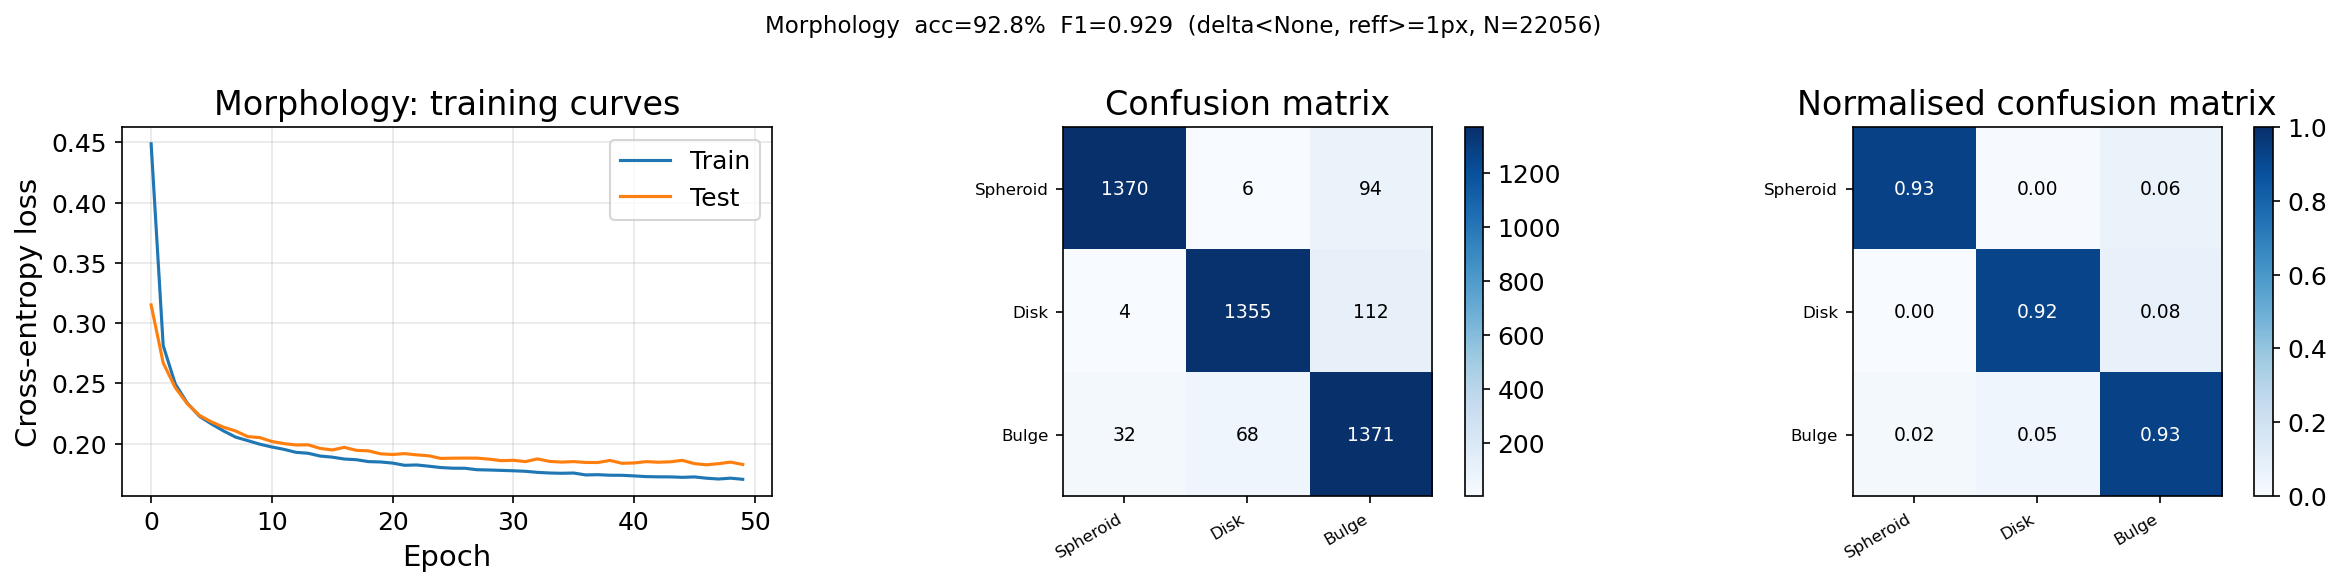

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Training curves
ax = axes[0]
ax.plot(tr_loss_m, label='Train')
ax.plot(te_loss_m, label='Test')
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-entropy loss')
ax.set_title('Morphology: training curves')
ax.legend(); ax.grid(True, alpha=0.3)

# Confusion matrix (raw)
classes = sorted(np.unique(lbl_morph))
cm = confusion_matrix(y_te, y_pred_m)
ax = axes[1]
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
ax.set_xticklabels([MORPH_NAMES[c] for c in classes], rotation=30, ha='right', fontsize=8)
ax.set_yticklabels([MORPH_NAMES[c] for c in classes], fontsize=8)
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=9)
ax.set_title('Confusion matrix'); plt.colorbar(im, ax=ax)

# Normalised confusion matrix
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ax = axes[2]
im2 = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
ax.set_xticklabels([MORPH_NAMES[c] for c in classes], rotation=30, ha='right', fontsize=8)
ax.set_yticklabels([MORPH_NAMES[c] for c in classes], fontsize=8)
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, f'{cm_n[i,j]:.2f}', ha='center', va='center',
                color='white' if cm_n[i, j] > 0.5 else 'black', fontsize=9)
ax.set_title('Normalised confusion matrix'); plt.colorbar(im2, ax=ax)

plt.suptitle(f'Morphology  acc={acc*100:.1f}%  F1={f1:.3f}  '
             f'(delta<{MORPH_DELTA_THRESHOLD}, reff>={REFF_MIN_PIX}px, N={len(emb_morph)})',
             fontsize=11)
plt.tight_layout()
plt.show()

---
## Section B · Axis Ratio Regression
`axis_ratio` (b/a ∈ [0,1]) — how well do embeddings encode galaxy inclination?

In [32]:
class AxisRatioDataset(Dataset):
    def __init__(self, root, crop_size, err_thresh, reff_min, reff_max,
                 max_samples, exclude_irregular=False, seed=42):
        self.to_rgb   = TO_RGB
        self.in_chans = IN_CHANS
        self.crop     = transforms.CenterCrop(crop_size)
        self._rng     = np.random.default_rng(seed)
        self._files   = []
        for fp in sorted(glob.glob(os.path.join(root, '*.h5'))):
            f = h5py.File(fp, 'r')
            if 'axis_ratio' in f: self._files.append(f)
            else: f.close()

        self._idx = []   # (file_idx, local_idx, axis_ratio)
        for fi, f in enumerate(tqdm(self._files, desc='Indexing AR')):
            ar    = f['axis_ratio'][:]
            err   = f['axis_ratio_err'][:] if 'axis_ratio_err' in f else None
            morph = f['morph_flag_f150w'][:] if 'morph_flag_f150w' in f else None
            vmask = np.isfinite(ar) & (ar > 0.1) & (ar < 0.9)
            if err is not None:
                vmask &= np.isfinite(err)
                if err_thresh is not None: vmask &= err/ar <= err_thresh
            if reff_min is not None or reff_max is not None:
                if 'radius_sersic' in f:
                    re = f['radius_sersic'][:] * DEG_TO_PIXEL
                    if reff_min is not None: vmask &= np.isfinite(re) & (re >= reff_min)
                    if reff_max is not None: vmask &= np.isfinite(re) & (re <= reff_max)
                else:
                    vmask[:] = False
            if exclude_irregular and morph is not None:
                vmask &= (morph != 2)
            for li in np.where(vmask)[0]:
                self._idx.append((fi, li, float(ar[li])))

        print(f'Valid AR samples: {len(self._idx)}' + (' (Irregular excluded)' if exclude_irregular else ''))
        if max_samples > 0 and max_samples < len(self._idx):
            chosen = self._rng.choice(len(self._idx), size=max_samples, replace=False)
            self._idx = [self._idx[i] for i in chosen]
            print(f'Subsampled to {len(self._idx)}')

    def __len__(self): return len(self._idx)

    def __getitem__(self, i):
        fi, li, ar = self._idx[i]
        img = self._files[fi]['image'][li].astype('float32')
        n   = self.in_chans if self.in_chans > 1 else 1
        img = np.repeat(img[np.newaxis], n, axis=0)
        t   = self.crop(torch.from_numpy(img))
        t   = torch.from_numpy(self.to_rgb(t.numpy()))
        return t, torch.tensor(ar, dtype=torch.float32)

    def close(self):
        for f in self._files:
            try: f.close()
            except: pass


ds_ar = AxisRatioDataset(
    DATA_ROOT, CROP_SIZE,
    err_thresh=AR_ERR_THRESH,
    reff_min=REFF_MIN_PIX, reff_max=REFF_MAX_PIX,
    max_samples=AR_MAX_SAMPLES, exclude_irregular=EXCLUDE_IRREGULAR, seed=SEED
)
print(f'Axis ratio dataset: {len(ds_ar)} samples')


Indexing AR: 100%|██████████| 20/20 [00:00<00:00, 121.55it/s]

Valid AR samples: 30959 (Irregular excluded)
Subsampled to 10000
Axis ratio dataset: 10000 samples


In [33]:
emb_ar, tgt_ar = compute_embeddings(ds_ar)
ds_ar.close()
print(f'Embeddings: {emb_ar.shape}')

X_tr, X_te, y_tr, y_te = train_test_split(emb_ar, tgt_ar, test_size=0.2, random_state=SEED)
_, tr_loss_ar, te_loss_ar, y_pred_ar = train_linear(
    X_tr, y_tr, X_te, y_te, task='reg', lr=1e-3, wd=1e-4, epochs=NUM_EPOCHS)

r2  = r2_score(y_te, y_pred_ar)
mae = mean_absolute_error(y_te, y_pred_ar)
rmse = np.sqrt(np.mean((y_te - y_pred_ar)**2))
print(f'\n=== Axis Ratio Results ===')
print(f'R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}')

# Save for poster plots
y_te_ar = y_te.copy()
y_pred_ar_saved = y_pred_ar.copy()
r2_ar, mae_ar, rmse_ar = r2, mae, rmse

Embeddings: 100%|██████████| 40/40 [00:29<00:00,  1.35it/s]


Embeddings: (10000, 512)


100%|██████████| 50/50 [00:12<00:00,  3.98it/s]


=== Axis Ratio Results ===
R²=0.8692  MAE=0.0571  RMSE=0.0779


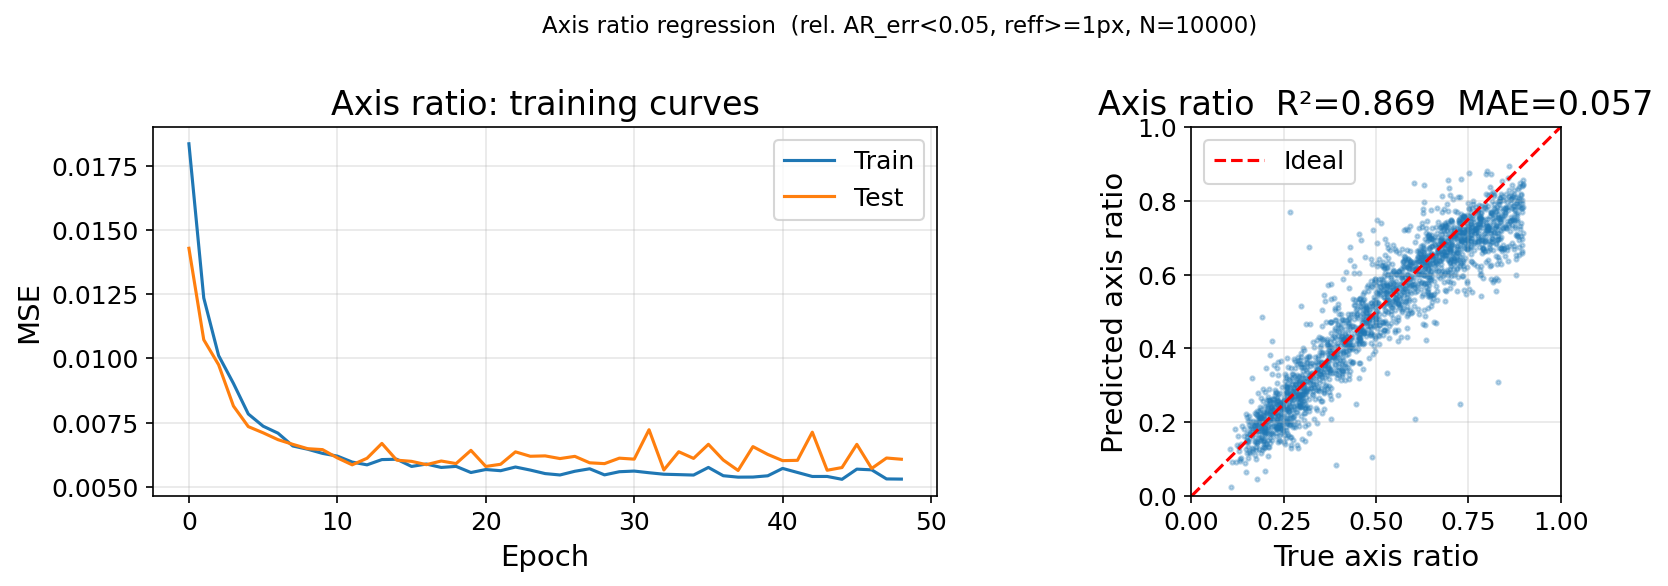

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(tr_loss_ar[1:], label='Train'); ax.plot(te_loss_ar[1:], label='Test')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.set_title('Axis ratio: training curves')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(y_te, y_pred_ar, s=4, alpha=0.3)
lims = [0, 1]
ax.plot(lims, lims, 'r--', label='Ideal')
ax.set_xlabel('True axis ratio'); ax.set_ylabel('Predicted axis ratio')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.set_title(f'Axis ratio  R²={r2:.3f}  MAE={mae:.3f}')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'Axis ratio regression  (rel. AR_err<{AR_ERR_THRESH}, reff>={REFF_MIN_PIX}px, N={len(emb_ar)})',
             fontsize=11)
plt.tight_layout()
plt.show()

---
## Section C · Effective Radius Regression
`log₁₀(radius_sersic [pixels])` — does the model encode galaxy size?

In [35]:
class RadiusDataset(Dataset):
    def __init__(self, root, crop_size, rel_err_thresh, reff_min, reff_max,
                 max_samples, exclude_irregular=False, seed=42):
        self.to_rgb   = TO_RGB
        self.in_chans = IN_CHANS
        self.crop     = transforms.CenterCrop(crop_size)
        self._rng     = np.random.default_rng(seed)
        self._files   = []
        for fp in sorted(glob.glob(os.path.join(root, '*.h5'))):
            f = h5py.File(fp, 'r')
            if 'radius_sersic' in f: self._files.append(f)
            else: f.close()

        self._idx = []   # (file_idx, local_idx, log10_re_pix)
        for fi, f in enumerate(tqdm(self._files, desc='Indexing RE')):
            rs    = f['radius_sersic'][:]
            err   = f['radius_sersic_err'][:] if 'radius_sersic_err' in f else None
            morph = f['morph_flag_f150w'][:]   if 'morph_flag_f150w' in f else None
            vmask = np.isfinite(rs) & (rs > 0)
            if err is not None:
                vmask &= np.isfinite(err)
                if rel_err_thresh is not None:
                    rel_err = np.where(rs > 0, err / rs, np.inf)
                    vmask &= rel_err <= rel_err_thresh
            re_pix = rs * DEG_TO_PIXEL
            if reff_min is not None: vmask &= np.isfinite(re_pix) & (re_pix >= reff_min)
            if reff_max is not None: vmask &= np.isfinite(re_pix) & (re_pix <= reff_max)
            if exclude_irregular and morph is not None:
                vmask &= np.isfinite(morph) & (morph != 2)
            for li in np.where(vmask)[0]:
                log_r = np.log10(float(rs[li]) * DEG_TO_PIXEL)
                self._idx.append((fi, li, log_r))

        print(f'Valid RE samples: {len(self._idx)}' + (' (Irregular excluded)' if exclude_irregular else ''))
        if max_samples > 0 and max_samples < len(self._idx):
            chosen = self._rng.choice(len(self._idx), size=max_samples, replace=False)
            self._idx = [self._idx[i] for i in chosen]
            print(f'Subsampled to {len(self._idx)}')

    def __len__(self): return len(self._idx)

    def __getitem__(self, i):
        fi, li, log_r = self._idx[i]
        img = self._files[fi]['image'][li].astype('float32')
        n   = self.in_chans if self.in_chans > 1 else 1
        img = np.repeat(img[np.newaxis], n, axis=0)
        t   = self.crop(torch.from_numpy(img))
        t   = torch.from_numpy(self.to_rgb(t.numpy()))
        return t, torch.tensor(log_r, dtype=torch.float32)

    def close(self):
        for f in self._files:
            try: f.close()
            except: pass


ds_re = RadiusDataset(
    DATA_ROOT, CROP_SIZE,
    rel_err_thresh=RE_REL_ERR_THRESH,
    reff_min=REFF_MIN_PIX, reff_max=REFF_MAX_PIX,
    max_samples=RE_MAX_SAMPLES, exclude_irregular=EXCLUDE_IRREGULAR, seed=SEED
)
print(f'Radius dataset: {len(ds_re)} samples')


Indexing RE:   0%|          | 0/20 [00:00<?, ?it/s]

Indexing RE: 100%|██████████| 20/20 [00:00<00:00, 120.32it/s]

Valid RE samples: 34365 (Irregular excluded)
Subsampled to 10000
Radius dataset: 10000 samples


In [36]:
emb_re, tgt_re = compute_embeddings(ds_re)
ds_re.close()
print(f'Embeddings: {emb_re.shape}')

X_tr, X_te, y_tr, y_te = train_test_split(emb_re, tgt_re, test_size=0.2, random_state=SEED)
_, tr_loss_re, te_loss_re, y_pred_re = train_linear(
    X_tr, y_tr, X_te, y_te, task='reg', lr=1e-3, wd=1e-4, epochs=NUM_EPOCHS)

r2_re  = r2_score(y_te, y_pred_re)
mae_re = mean_absolute_error(y_te, y_pred_re)
rmse_re = np.sqrt(np.mean((y_te - y_pred_re)**2))
print(f'\n=== Effective Radius Results ===')
print(f'R²={r2_re:.4f}  MAE={mae_re:.4f}  RMSE={rmse_re:.4f} (log₁₀ space)')

# Save for poster plots
y_te_re = y_te.copy()
y_pred_re_saved = y_pred_re.copy()

Embeddings: 100%|██████████| 40/40 [00:30<00:00,  1.32it/s]


Embeddings: (10000, 512)


100%|██████████| 50/50 [00:09<00:00,  5.26it/s]


=== Effective Radius Results ===
R²=0.8695  MAE=0.0842  RMSE=0.1290 (log₁₀ space)


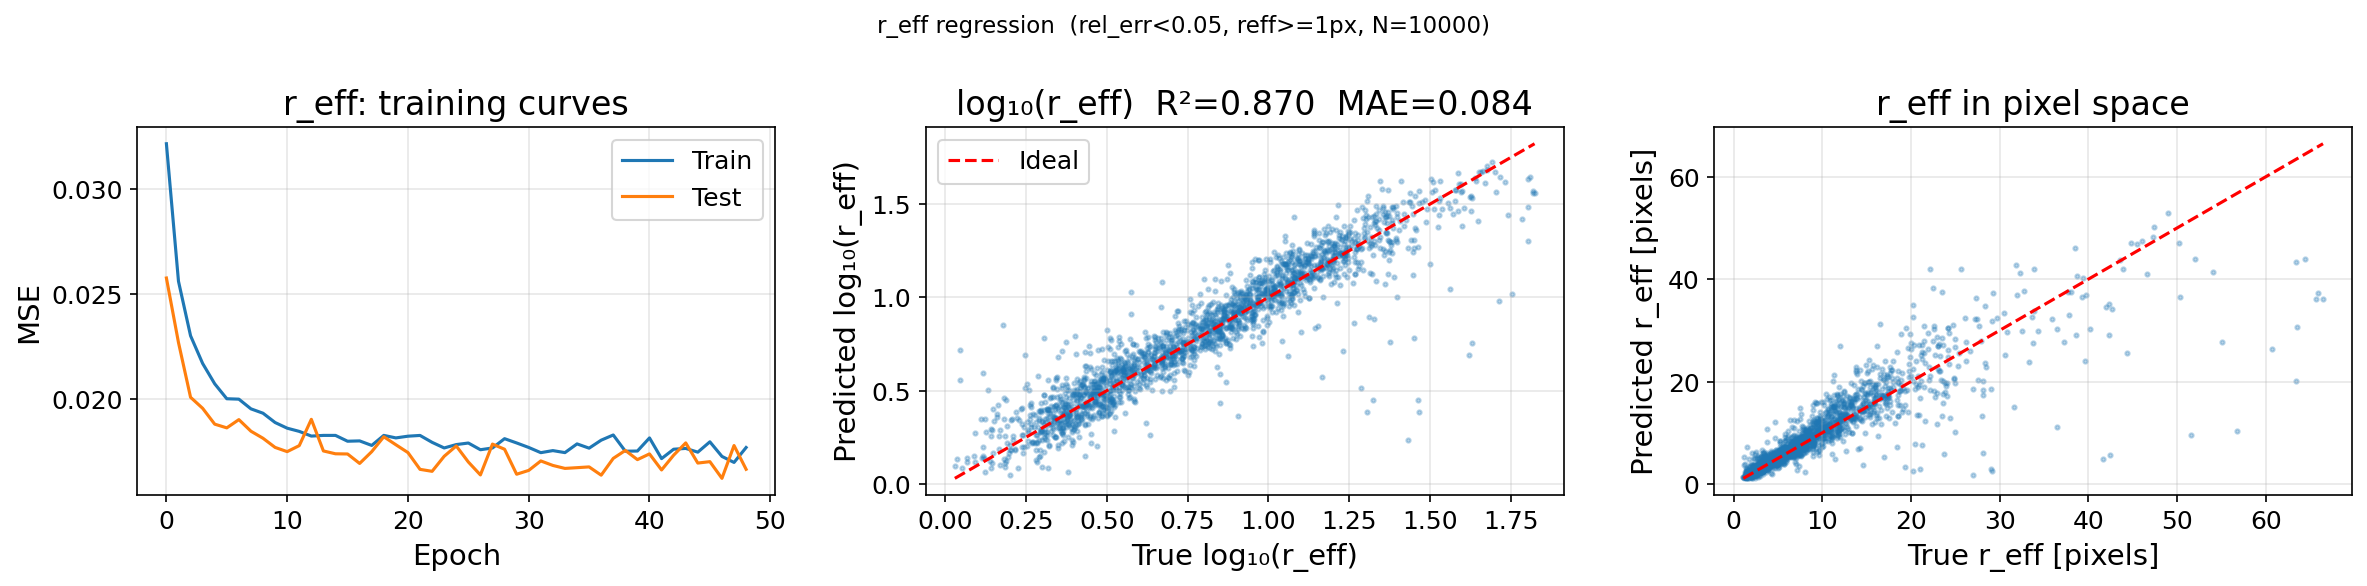

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(tr_loss_re[1:], label='Train'); ax.plot(te_loss_re[1:], label='Test')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.set_title('r_eff: training curves')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(y_te, y_pred_re, s=4, alpha=0.3)
lims = [y_te.min(), y_te.max()]
ax.plot(lims, lims, 'r--', label='Ideal')
ax.set_xlabel('True log₁₀(r_eff)'); ax.set_ylabel('Predicted log₁₀(r_eff)')
ax.set_title(f'log₁₀(r_eff)  R²={r2_re:.3f}  MAE={mae_re:.3f}')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.scatter(10**y_te, 10**y_pred_re, s=4, alpha=0.3)
ax.plot([10**lims[0], 10**lims[1]], [10**lims[0], 10**lims[1]], 'r--')
ax.set_xlabel('True r_eff [pixels]'); ax.set_ylabel('Predicted r_eff [pixels]')
ax.set_title('r_eff in pixel space')
ax.grid(True, alpha=0.3)

plt.suptitle(f'r_eff regression  (rel_err<{RE_REL_ERR_THRESH}, reff>={REFF_MIN_PIX}px, N={len(emb_re)})',
             fontsize=11)
plt.tight_layout()
plt.show()

---
## Section D · Stellar Mass Regression
`mass_minchi2` (log stellar mass [Msol]) — does the model encode stellar mass?

In [38]:
class MassDataset(Dataset):
    def __init__(self, root, crop_size, mass_min, mass_max, reff_min, reff_max,
                 max_samples, exclude_irregular=False, seed=42):
        self.to_rgb   = TO_RGB
        self.in_chans = IN_CHANS
        self.crop     = transforms.CenterCrop(crop_size)
        self._rng     = np.random.default_rng(seed)
        self._files   = []
        for fp in sorted(glob.glob(os.path.join(root, '*.h5'))):
            f = h5py.File(fp, 'r')
            if 'mass_minchi2' in f: self._files.append(f)
            else: f.close()

        self._idx = []  # (file_idx, local_idx, log_mass)
        for fi, f in enumerate(tqdm(self._files, desc='Indexing MASS')):
            mass  = f['mass_minchi2'][:]
            morph = f['morph_flag_f150w'][:] if 'morph_flag_f150w' in f else None
            vmask = np.isfinite(mass)
            if mass_min is not None: vmask &= mass >= mass_min
            if mass_max is not None: vmask &= mass <= mass_max
            if reff_min is not None or reff_max is not None:
                if 'radius_sersic' in f:
                    re = f['radius_sersic'][:] * DEG_TO_PIXEL
                    if reff_min is not None: vmask &= np.isfinite(re) & (re >= reff_min)
                    if reff_max is not None: vmask &= np.isfinite(re) & (re <= reff_max)
                else:
                    vmask[:] = False
            if exclude_irregular and morph is not None:
                vmask &= np.isfinite(morph) & (morph != 2)
            for li in np.where(vmask)[0]:
                self._idx.append((fi, li, float(mass[li])))

        print(f'Valid MASS samples: {len(self._idx)}' + (' (Irregular excluded)' if exclude_irregular else ''))
        if max_samples > 0 and max_samples < len(self._idx):
            chosen = self._rng.choice(len(self._idx), size=max_samples, replace=False)
            self._idx = [self._idx[i] for i in chosen]
            print(f'Subsampled to {len(self._idx)}')

    def __len__(self): return len(self._idx)

    def __getitem__(self, i):
        fi, li, mass = self._idx[i]
        img = self._files[fi]['image'][li].astype('float32')
        n   = self.in_chans if self.in_chans > 1 else 1
        img = np.repeat(img[np.newaxis], n, axis=0)
        t   = self.crop(torch.from_numpy(img))
        t   = torch.from_numpy(self.to_rgb(t.numpy()))
        return t, torch.tensor(mass, dtype=torch.float32)

    def close(self):
        for f in self._files:
            try: f.close()
            except: pass


ds_mass = MassDataset(
    DATA_ROOT, CROP_SIZE,
    mass_min=MASS_MIN_LOGM, mass_max=MASS_MAX_LOGM,
    reff_min=REFF_MIN_PIX, reff_max=REFF_MAX_PIX,
    max_samples=MASS_MAX_SAMPLES,
    exclude_irregular=EXCLUDE_IRREGULAR, seed=SEED
)
print(f'Mass dataset: {len(ds_mass)} samples')


Indexing MASS: 100%|██████████| 20/20 [00:00<00:00, 101.80it/s]


Valid MASS samples: 38757 (Irregular excluded)
Subsampled to 10000
Mass dataset: 10000 samples


Embeddings: 100%|██████████| 40/40 [00:29<00:00,  1.34it/s]


Embeddings: (10000, 512)


100%|██████████| 50/50 [00:11<00:00,  4.28it/s]



=== Stellar Mass Results ===
R²=0.5116  MAE=0.4791  RMSE=0.6128 (log mass)


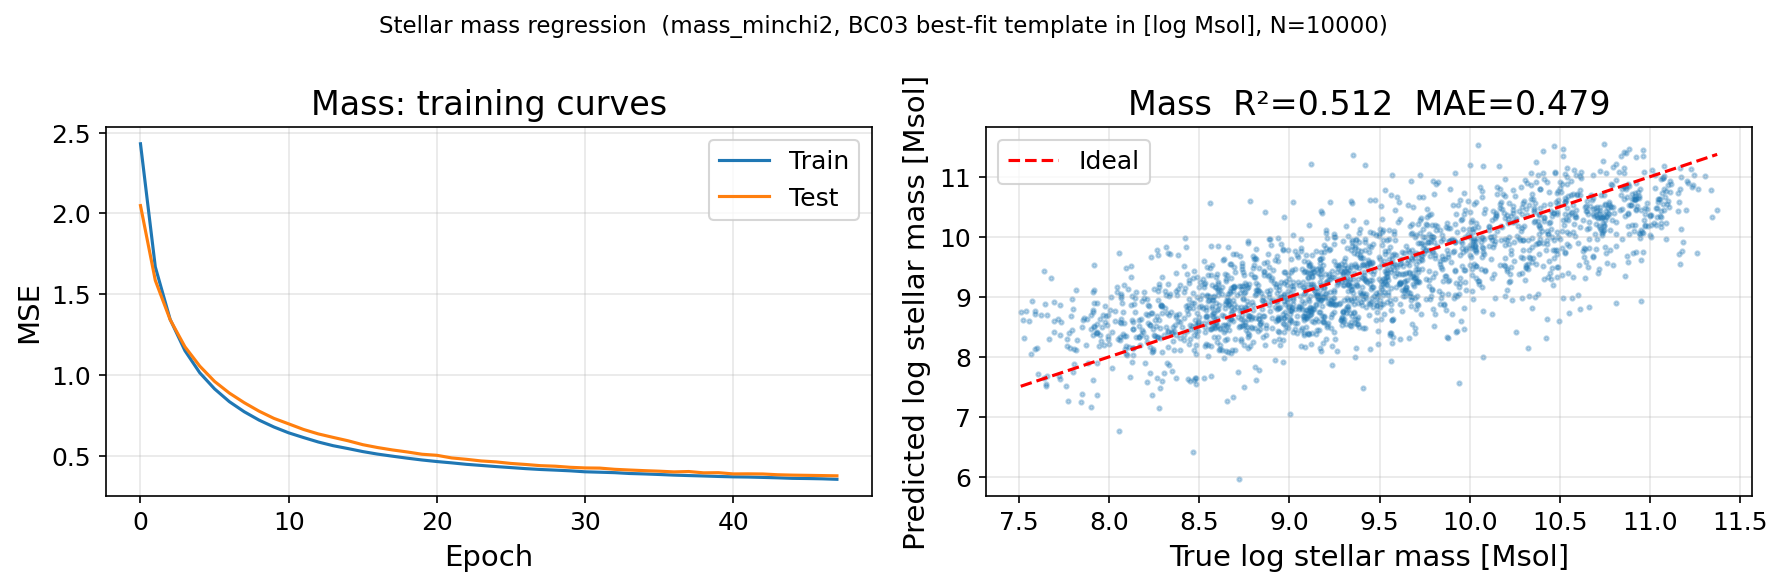

In [39]:
emb_mass, tgt_mass = compute_embeddings(ds_mass)
ds_mass.close()
print(f'Embeddings: {emb_mass.shape}')

X_tr, X_te, y_tr, y_te = train_test_split(emb_mass, tgt_mass, test_size=0.2, random_state=SEED)
_, tr_loss_mass, te_loss_mass, y_pred_mass = train_linear(
    X_tr, y_tr, X_te, y_te, task='reg', lr=1e-3, wd=1e-4, epochs=NUM_EPOCHS)

r2_mass  = r2_score(y_te, y_pred_mass)
mae_mass = mean_absolute_error(y_te, y_pred_mass)
rmse_mass = np.sqrt(np.mean((y_te - y_pred_mass)**2))
print(f'\n=== Stellar Mass Results ===')
print(f'R²={r2_mass:.4f}  MAE={mae_mass:.4f}  RMSE={rmse_mass:.4f} (log mass)')

# Save for poster plots
y_te_mass_saved = y_te.copy()
y_pred_mass_saved = y_pred_mass.copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(tr_loss_mass[2:], label='Train'); ax.plot(te_loss_mass[2:], label='Test')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.set_title('Mass: training curves')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(y_te, y_pred_mass, s=4, alpha=0.3)
lims = [y_te.min(), y_te.max()]
ax.plot(lims, lims, 'r--', label='Ideal')
ax.set_xlabel('True log stellar mass [Msol]')
ax.set_ylabel('Predicted log stellar mass [Msol]')
ax.set_title(f'Mass  R²={r2_mass:.3f}  MAE={mae_mass:.3f}')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'Stellar mass regression  (mass_minchi2, BC03 best-fit template in [log Msol], N={len(emb_mass)})', fontsize=11)
plt.tight_layout()
plt.show()

---
## Summary

In [40]:
print('='*65)
print('LINEAR PROBE SUMMARY')
print('='*65)
print(f'Shared filters: reff ∈ [{REFF_MIN_PIX}, {REFF_MAX_PIX}] px')
print()
print(f'  A. Morphology classification')
print(f'     N={len(emb_morph)}  delta<{MORPH_DELTA_THRESHOLD}  balanced={MORPH_BALANCED}')
print(f'     Accuracy: {acc*100:.2f}%  |  F1: {f1:.4f}')
print()
print(f'  B. Axis ratio regression')
print(f'     N={len(emb_ar)}  AR_err<{AR_ERR_THRESH}')
print(f'     R²: {r2:.4f}  |  MAE: {mae:.4f}  |  RMSE: {rmse:.4f}')
print()
print(f'  C. Effective radius regression')
print(f'     N={len(emb_re)}  RE_rel_err<{RE_REL_ERR_THRESH}')
print(f'     R²: {r2_re:.4f}  |  MAE: {mae_re:.4f}  |  RMSE: {rmse_re:.4f}  (log₁₀ space)')
print()
print(f'  D. Stellar mass regression')
print(f'     N={len(emb_mass)}  mass_range=[{MASS_MIN_LOGM}, {MASS_MAX_LOGM}]')
print(f'     R²: {r2_mass:.4f}  |  MAE: {mae_mass:.4f}  |  RMSE: {rmse_mass:.4f}  (log mass)')
print('='*65)

LINEAR PROBE SUMMARY
Shared filters: reff ∈ [1, 72] px

  A. Morphology classification
     N=22056  delta<None  balanced=True
     Accuracy: 92.84%  |  F1: 0.9289

  B. Axis ratio regression
     N=10000  AR_err<0.05
     R²: 0.8692  |  MAE: 0.0571  |  RMSE: 0.0779

  C. Effective radius regression
     N=10000  RE_rel_err<0.05
     R²: 0.8695  |  MAE: 0.0842  |  RMSE: 0.1290  (log₁₀ space)

  D. Stellar mass regression
     N=10000  mass_range=[7.5, 11.5]
     R²: 0.5116  |  MAE: 0.4791  |  RMSE: 0.6128  (log mass)


In [41]:
# ═══════════════════════════════════════════════════════════════════
# Poster-ready figure style
# ═══════════════════════════════════════════════════════════════════
import matplotlib as mpl

POSTER_DIR = os.path.join(BENCH_ROOT, 'poster_figs')
os.makedirs(POSTER_DIR, exist_ok=True)

POSTER_RC = {
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
}
mpl.rcParams.update(POSTER_RC)
print(f'Poster figures will be saved to {POSTER_DIR}')

Poster figures will be saved to /home/yacheng/ssl_outthere/encoder_image/astrodino/benchmark/poster_figs


---
## Poster Figures — Morphology Classification
Training loss + normalized confusion matrix

Saved → /home/yacheng/ssl_outthere/encoder_image/astrodino/benchmark/poster_figs/poster_morphology.{pdf,png}


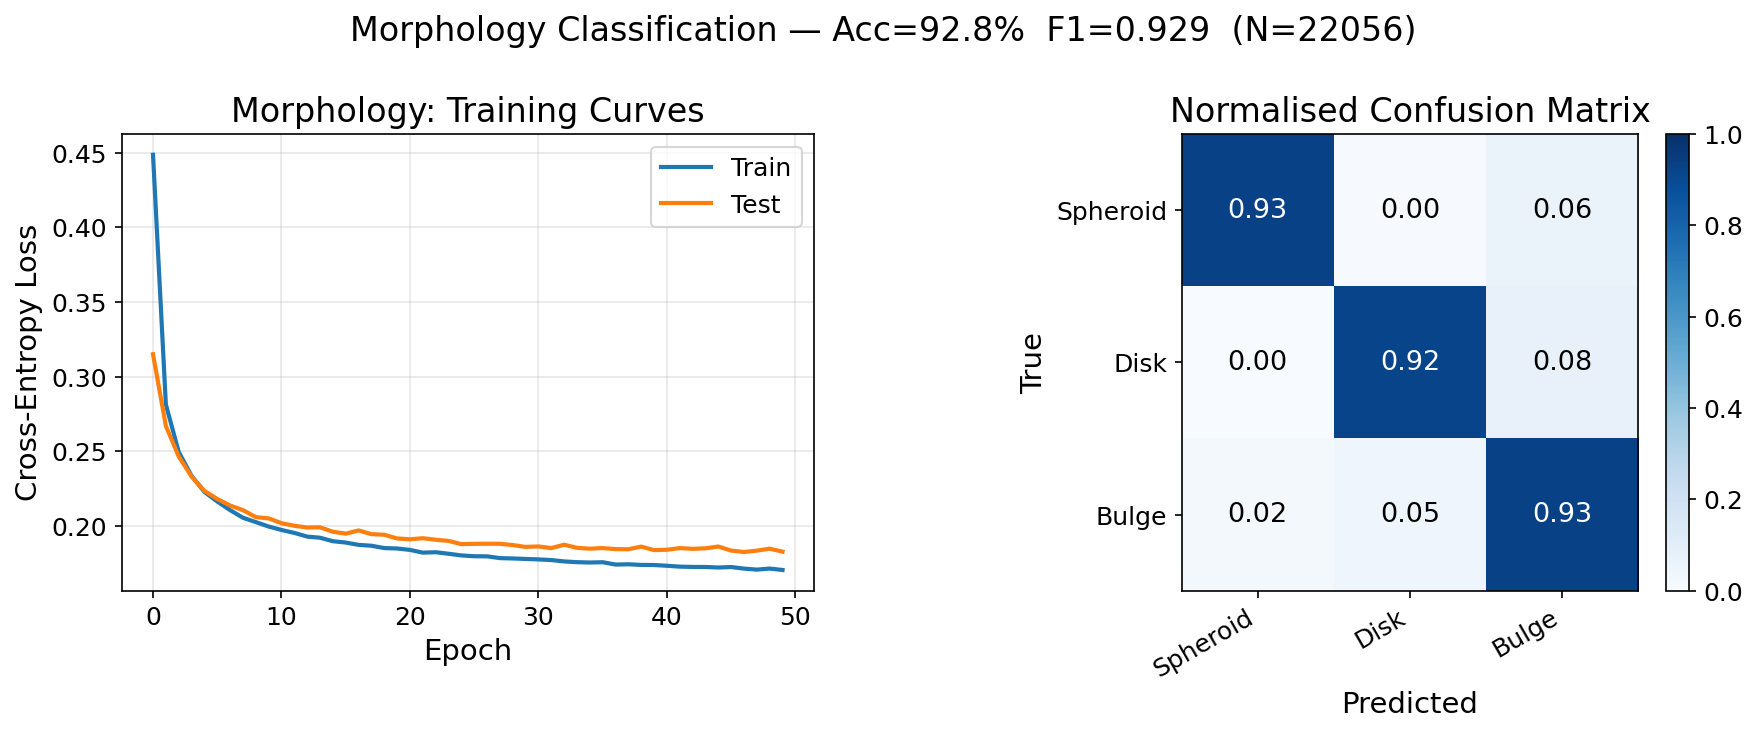

In [42]:
# ─── Poster Figure 1: Morphology — training curves + normalised confusion matrix ───
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: training curves ---
ax = axes[0]
ax.plot(tr_loss_m, label='Train', lw=2)
ax.plot(te_loss_m, label='Test',  lw=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Morphology: Training Curves')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Right: normalised confusion matrix ---
classes_poster = sorted(np.unique(lbl_morph))
cm = confusion_matrix(y_te_morph, y_pred_morph, labels=classes_poster)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

ax = axes[1]
im = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(classes_poster)))
ax.set_yticks(range(len(classes_poster)))
ax.set_xticklabels([MORPH_NAMES[c] for c in classes_poster], rotation=30, ha='right')
ax.set_yticklabels([MORPH_NAMES[c] for c in classes_poster])
for i in range(len(classes_poster)):
    for j in range(len(classes_poster)):
        ax.text(j, i, f'{cm_n[i,j]:.2f}', ha='center', va='center',
                color='white' if cm_n[i, j] > 0.5 else 'black', fontsize=13)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Normalised Confusion Matrix')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f'Morphology Classification — Acc={acc*100:.1f}%  F1={f1:.3f}  (N={len(emb_morph)})', fontsize=16)
fig.tight_layout()
fig.savefig(os.path.join(POSTER_DIR, 'poster_morphology.png'),transparent=True)
print(f'Saved → {POSTER_DIR}/poster_morphology.{{pdf,png}}')
plt.show()

---
## Poster Figures — Effective Radius Regression
Training loss + predicted vs true log₁₀(r_eff)

Saved → /home/yacheng/ssl_outthere/encoder_image/astrodino/benchmark/poster_figs/poster_reff.{pdf,png}


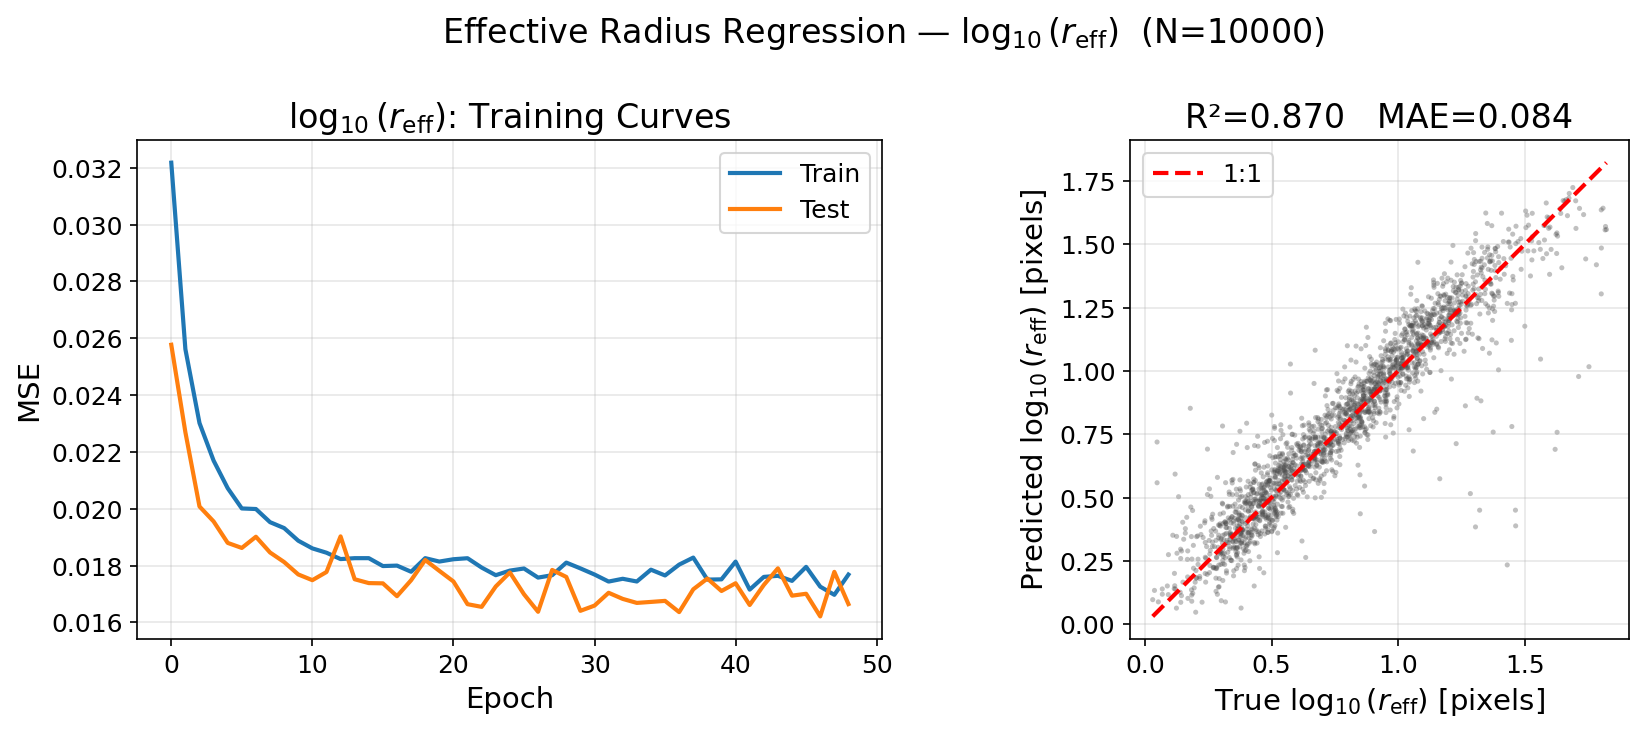

In [43]:
# ─── Poster Figure 2: Effective Radius — training curves + 1v1 diagram ───
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: training curves ---
ax = axes[0]
ax.plot(tr_loss_re[1:], label='Train', lw=2)
ax.plot(te_loss_re[1:], label='Test',  lw=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title(r'$\log_{10}(r_{\rm eff})$: Training Curves')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Right: predicted vs true ---
ax = axes[1]
ax.scatter(y_te_re, y_pred_re_saved, s=6, alpha=0.35, edgecolors='none', color='#4C4C4C')
lims_re = [y_te_re.min(), y_te_re.max()]
ax.plot(lims_re, lims_re, 'r--', lw=2, label='1:1')
ax.set_xlabel(r'True $\log_{10}(r_{\rm eff})$ [pixels]')
ax.set_ylabel(r'Predicted $\log_{10}(r_{\rm eff})$ [pixels]')
ax.set_title(f'R²={r2_re:.3f}   MAE={mae_re:.3f}')
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle(rf'Effective Radius Regression — $\log_{{10}}(r_{{\rm eff}})$  (N={len(emb_re)})', fontsize=16)
fig.tight_layout()
fig.savefig(os.path.join(POSTER_DIR, 'poster_reff.png'),transparent=True)
print(f'Saved → {POSTER_DIR}/poster_reff.{{pdf,png}}')
plt.show()

---
## Poster Figures — Axis Ratio (q) Regression
Training loss + predicted vs true axis ratio

Saved → /home/yacheng/ssl_outthere/encoder_image/astrodino/benchmark/poster_figs/poster_axis_ratio.{pdf,png}


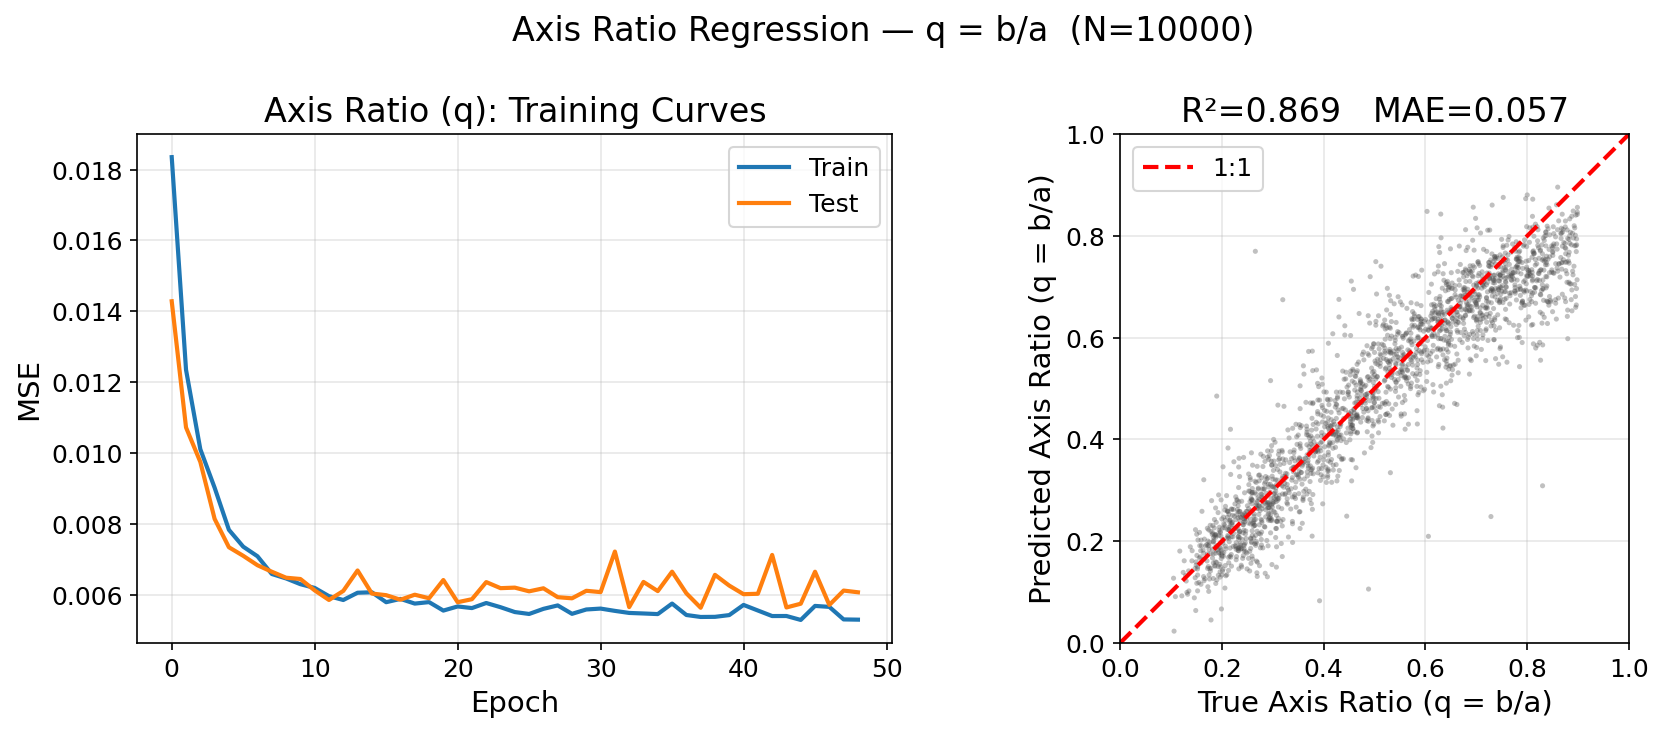

In [44]:
# ─── Poster Figure 3: Axis Ratio (q) — training curves + 1v1 diagram ───
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: training curves ---
ax = axes[0]
ax.plot(tr_loss_ar[1:], label='Train', lw=2)
ax.plot(te_loss_ar[1:], label='Test',  lw=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('Axis Ratio (q): Training Curves')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Right: predicted vs true ---
ax = axes[1]
ax.scatter(y_te_ar, y_pred_ar_saved, s=6, alpha=0.35, edgecolors='none', color='#4C4C4C')
ax.plot([0, 1], [0, 1], 'r--', lw=2, label='1:1')
ax.set_xlabel('True Axis Ratio (q = b/a)')
ax.set_ylabel('Predicted Axis Ratio (q = b/a)')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.set_title(f'R²={r2_ar:.3f}   MAE={mae_ar:.3f}')
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle(f'Axis Ratio Regression — q = b/a  (N={len(emb_ar)})', fontsize=16)
fig.tight_layout()
fig.savefig(os.path.join(POSTER_DIR, 'poster_axis_ratio.pdf'))
fig.savefig(os.path.join(POSTER_DIR, 'poster_axis_ratio.png'))
print(f'Saved → {POSTER_DIR}/poster_axis_ratio.{{pdf,png}}')
plt.show()

Saved → /home/yacheng/ssl_outthere/encoder_image/astrodino/benchmark/poster_figs/poster_combined.{pdf,png}


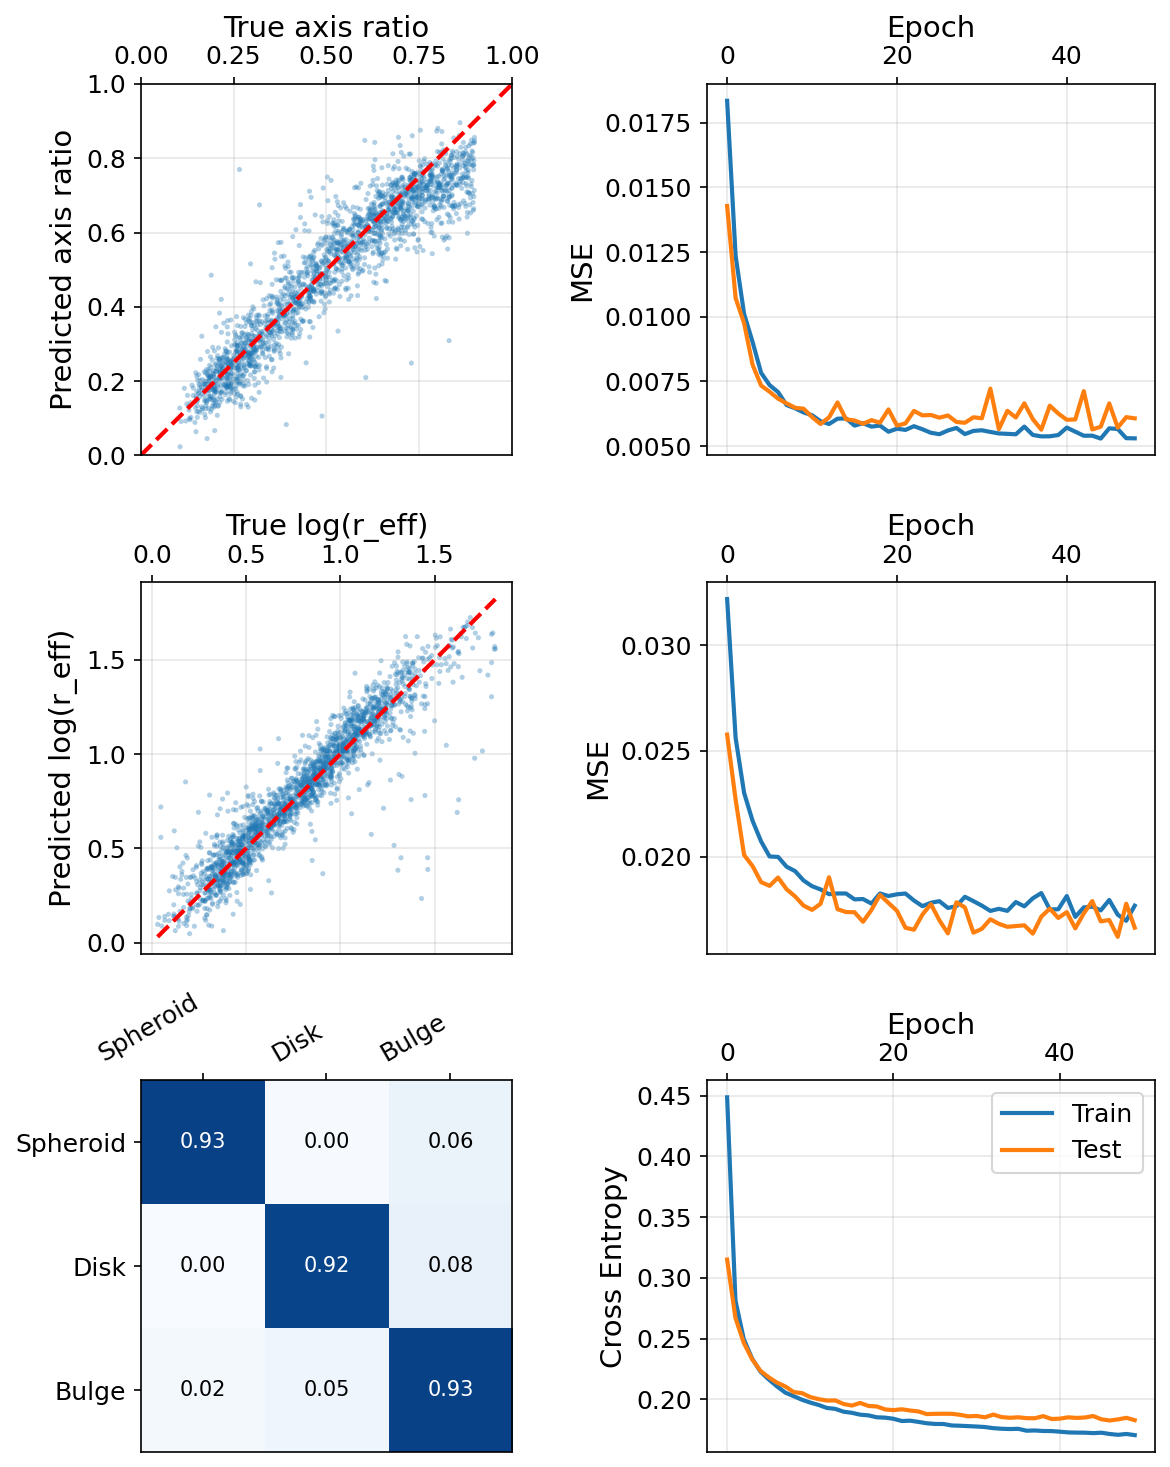

In [45]:
# ── Row 1: Morphology ──
fig, axes = plt.subplots(3, 2, figsize=(8, 10))
ax = axes[2, 1]
ax.plot(tr_loss_m[0:], label='Train', lw=2)
ax.plot(te_loss_m[0:], label='Test',  lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross Entropy')
ax.legend(); ax.grid(True, alpha=0.3)

# Normalised confusion matrix
classes = sorted(np.unique(lbl_morph))
cm = confusion_matrix(y_te_morph, y_pred_morph, labels=classes)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ax = axes[2, 0]
im = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
ax.set_xticklabels([MORPH_NAMES[c] for c in classes], rotation=30, ha='right')
ax.set_yticklabels([MORPH_NAMES[c] for c in classes])
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, f'{cm_n[i,j]:.2f}', ha='center', va='center',
                color='white' if cm_n[i, j] > 0.5 else 'black', fontsize=10)
#plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ── Row 2: Effective radius (log10 r_eff) ──
ax = axes[1, 1]
ax.plot(tr_loss_re[1:], label='Train', lw=2)
ax.plot(te_loss_re[1:], label='Test',  lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.scatter(y_te_re, y_pred_re_saved, s=6, alpha=0.35, edgecolors='none')
lims_re = [y_te_re.min(), y_te_re.max()]
ax.plot(lims_re, lims_re, 'r--', lw=2)
ax.set_xlabel('True log(r_eff)'); ax.set_ylabel('Predicted log(r_eff)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

# ── Row 3: Axis ratio (q) ──
ax = axes[0, 1]
ax.plot(tr_loss_ar[1:], label='Train', lw=2)
ax.plot(te_loss_ar[1:], label='Test',  lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.grid(True, alpha=0.3)

ax = axes[0, 0]
ax.scatter(y_te_ar, y_pred_ar_saved, s=6, alpha=0.35, edgecolors='none')
ax.plot([0, 1], [0, 1], 'r--', lw=2)
ax.set_xlabel('True axis ratio'); ax.set_ylabel('Predicted axis ratio')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)


#fig.suptitle(f'Linear probe summary — N_morph={len(emb_morph)}  N_re={len(emb_re)}  N_q={len(emb_ar)}', fontsize=16)

# Move x-axis labels & ticks from bottom to top for all subplots
for ax in axes.flat:
    ax.xaxis.set_label_position('top')
    ax.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)

fig.tight_layout()#rect=[0, 0, 1, 0.96])
outp = os.path.join(POSTER_DIR, 'poster_combined')
fig.savefig(outp + '.png', transparent=True)
print(f'Saved → {outp}.{{pdf,png}}')
plt.show()

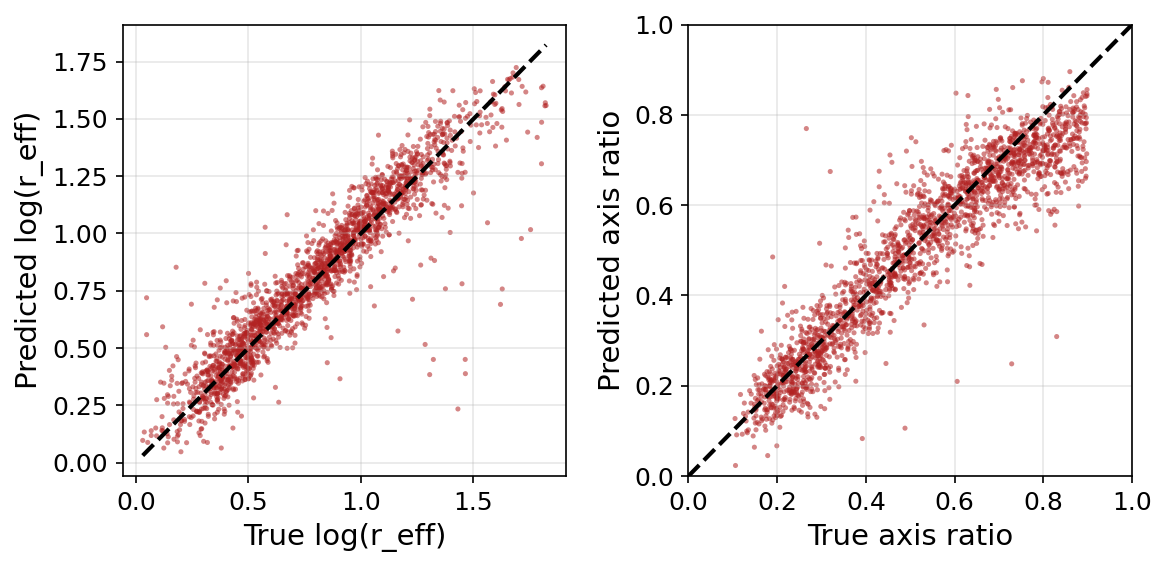

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

ax = axes[0]
ax.scatter(y_te_re, y_pred_re_saved, s=6, alpha=0.55, edgecolors='none',color='firebrick')
lims_re = [y_te_re.min(), y_te_re.max()]
ax.plot(lims_re, lims_re, '--', lw=2,color='black')
ax.set_xlabel('True log(r_eff)'); ax.set_ylabel('Predicted log(r_eff)')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(y_te_ar, y_pred_ar_saved, s=6, alpha=0.55, edgecolors='none',color='firebrick')
ax.plot([0, 1], [0, 1], '--', lw=2,color='black')
ax.set_xlabel('True axis ratio'); ax.set_ylabel('Predicted axis ratio')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(outp + '.png', transparent=True)


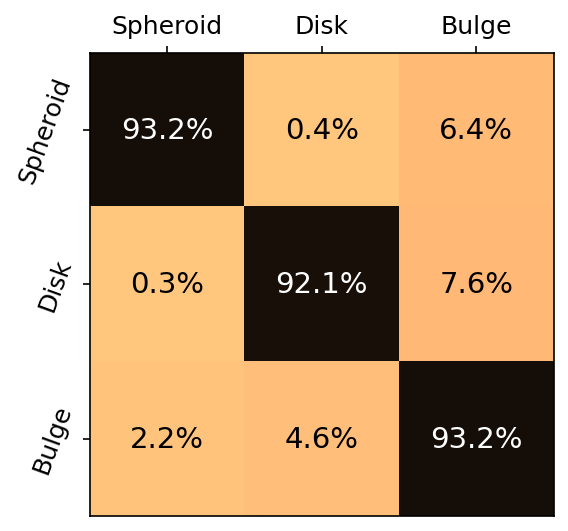

In [47]:
fig, axes = plt.subplots(1, 1, figsize=(4, 4))
ax = axes
# Normalised confusion matrix
classes = sorted(np.unique(lbl_morph))
cm = confusion_matrix(y_te_morph, y_pred_morph, labels=classes)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
im = ax.imshow(cm_n, cmap='copper_r', vmin=0, vmax=1)
ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
ax.set_xticklabels([MORPH_NAMES[c] for c in classes], rotation=0)#, ha='right')
ax.set_yticklabels([MORPH_NAMES[c] for c in classes],rotation=70,va='center')
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, f'{cm_n[i,j]*100:.1f}%', ha='center', va='center',
                color='white' if cm_n[i, j] > 0.5 else 'black', fontsize=14)

ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)
plt.tight_layout()
fig.savefig(outp + '.png', transparent=True)